# Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

This notebook covers:
1. Public Dataset Exploration and Preprocessing
2. Data Cleaning and Feature Engineering 
3. Exploratory Data Analysis (EDA)
4. Clustering Techniques (RFM Segmentation)
5. Collaborative Filtering-based Product Recommendation
6. Model Evaluation and Customer Segmentation Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Dataset Collection and Understanding

In [2]:
# Load the dataset
# Assuming the dataset is named 'online_retail.csv' and is in the same directory.
# In pandas, if it's a CSV with latin1 or utf8 encoding:
try:
    df = pd.read_csv('online_retail.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('online_retail.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2022-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2022-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2022-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


## 2. Data Preprocessing
- Remove rows with missing CustomerID
- Exclude cancelled invoices (InvoiceNo starting with 'C')
- Remove negative or zero quantities and prices

In [4]:
# Remove rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# Convert CustomerID to string/integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# Exclude cancelled invoices (InvoiceNo starting with 'C')
# Also handle cases where InvoiceNo might not be strings
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)
df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]

# Remove negative or zero quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Dataset shape after preprocessing: {df_clean.shape}")

Dataset shape after preprocessing: (397884, 8)


## 3. Exploratory Data Analysis (EDA)

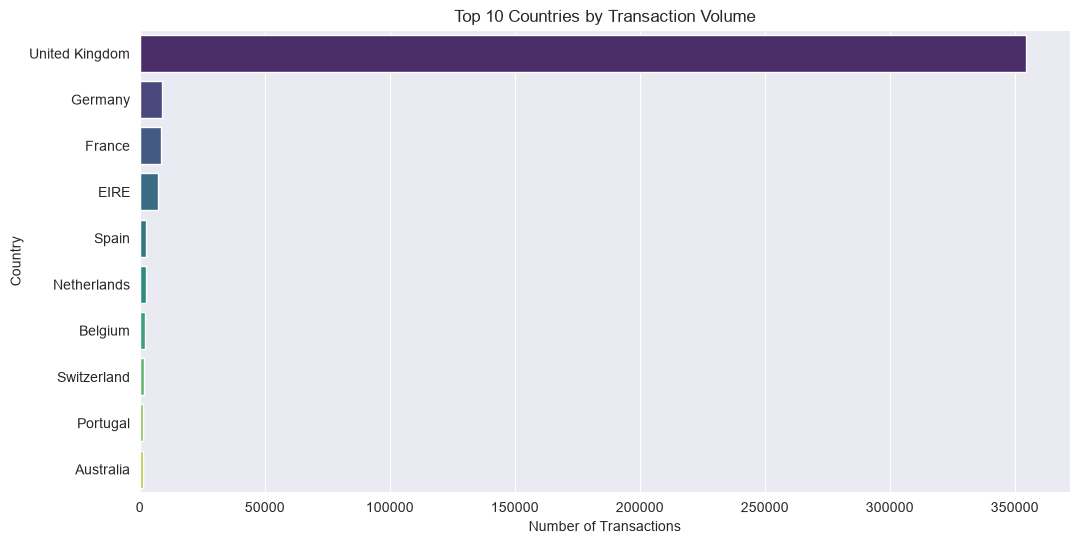

In [5]:
# Add TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Analyze transaction volume by country
top_countries = df_clean['Country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.savefig('top_countries.png', bbox_inches='tight')
plt.show()

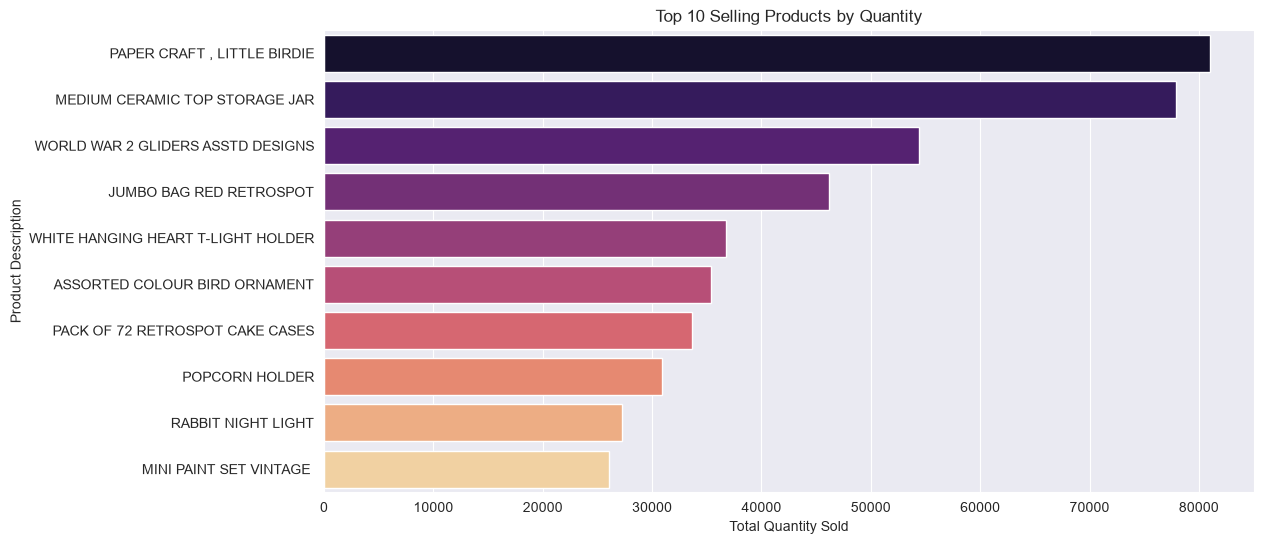

In [6]:
# Identify top-selling products
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()

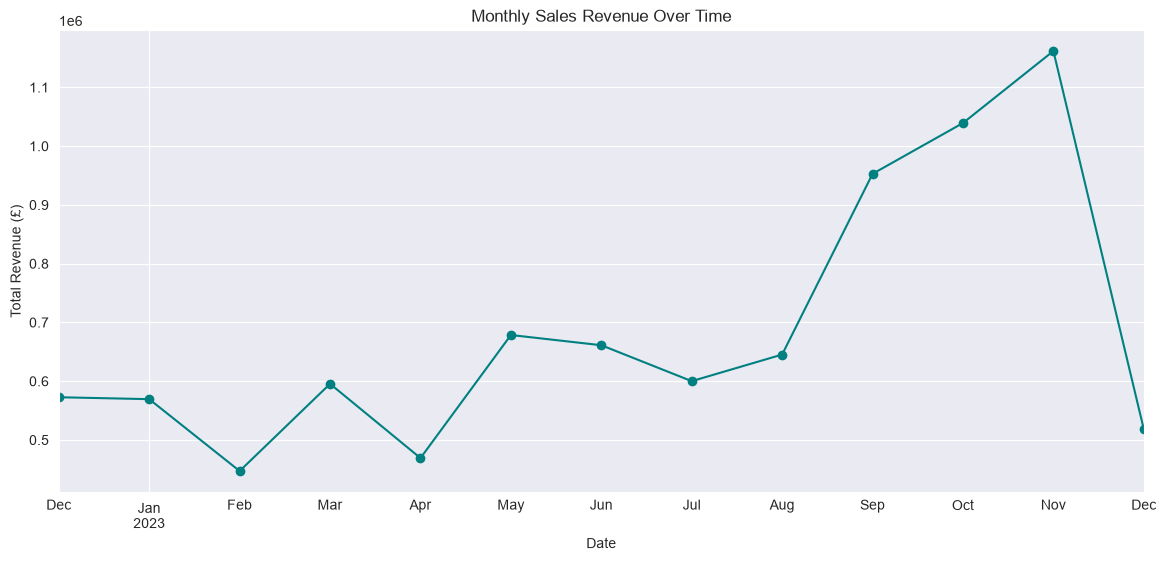

In [7]:
# Visualize purchase trends over time
monthly_sales = df_clean.resample('ME', on='InvoiceDate')['TotalPrice'].sum()
plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue (£)')
plt.grid(True)
plt.savefig('monthly_sales.png', bbox_inches='tight')
plt.show()

## 4. Feature Engineering: RFM Calculation

In [8]:
# Calculate Recency, Frequency, Monetary (RFM)
latest_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                # Frequency
    'TotalPrice': 'sum'                                    # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print(rfm.head())

  CustomerID  Recency  Frequency  Monetary
0      12346      326          1  77183.60
1      12347        2          7   4310.00
2      12348       75          4   1797.24
3      12349       19          1   1757.55
4      12350      310          1    334.40


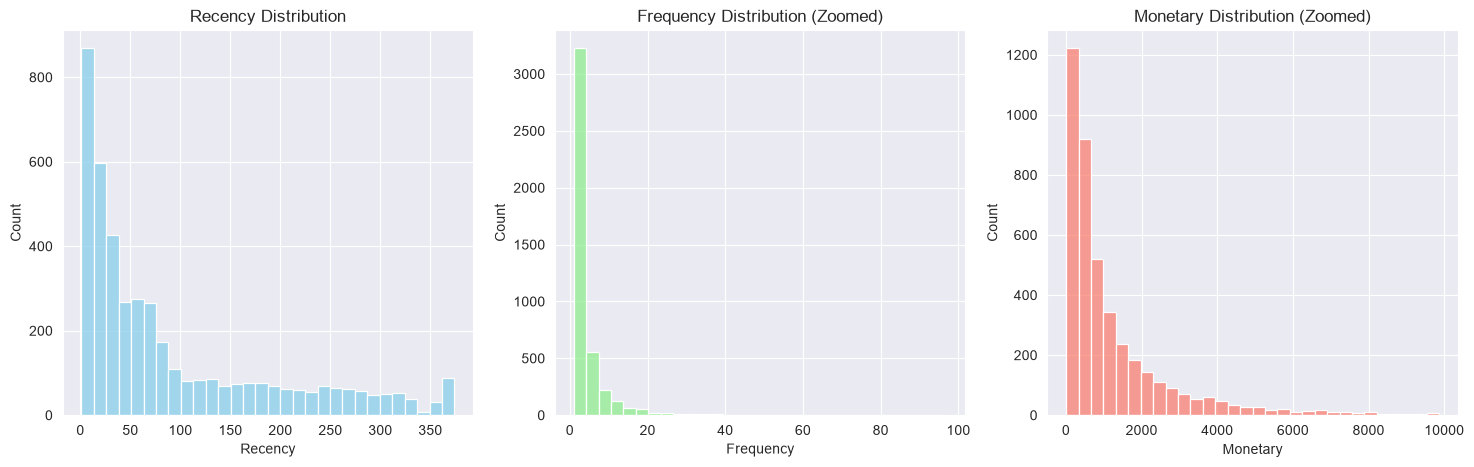

In [9]:
# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='skyblue').set_title('Recency Distribution')
sns.histplot(rfm[rfm['Frequency'] < 100]['Frequency'], bins=30, ax=axes[1], color='lightgreen').set_title('Frequency Distribution (Zoomed)')
sns.histplot(rfm[rfm['Monetary'] < 10000]['Monetary'], bins=30, ax=axes[2], color='salmon').set_title('Monetary Distribution (Zoomed)')
plt.savefig('rfm_distributions.png', bbox_inches='tight')
plt.show()

## 5. Clustering Methodology

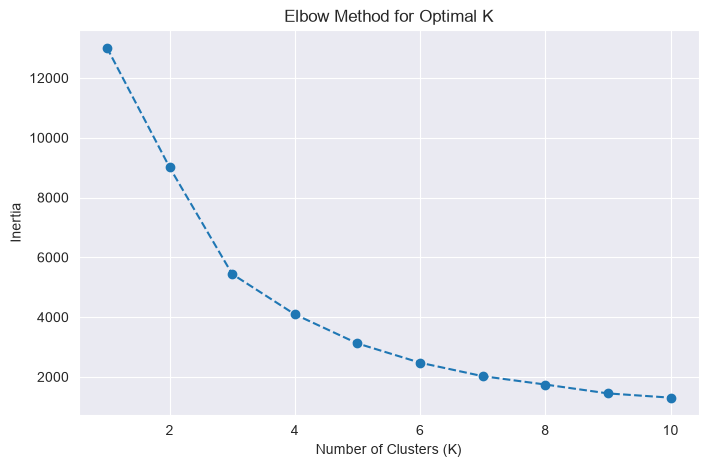

In [10]:
# Handle extreme outliers and scale the features
# For better clustering, we can apply log transformation to F and M (and sometimes R) to handle skewness
# But to keep it simple and aligned with standard scaling:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# Elbow Method to find optimal K
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.savefig('elbow_method.png', bbox_inches='tight')
plt.show()

In [11]:
# Based on common RFM practices, 4 clusters works well for segmentation: 
# High-Value, Regular, Occasional, At-Risk
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# Evaluate Silhouette Score
sil_score = silhouette_score(rfm_scaled_df, rfm['Cluster'])
print(f"Silhouette Score for K={optimal_k}: {sil_score:.3f}")

Silhouette Score for K=4: 0.616


In [12]:
# Analyze Cluster Characteristics
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary['Count'] = rfm['Cluster'].value_counts()
print(cluster_summary)

            Recency  Frequency       Monetary  Count
Cluster                                             
0         43.702685   3.682711    1359.049284   3054
1        248.075914   1.552015     480.617480   1067
2          7.384615  82.538462  127338.313846     13
3         15.500000  22.333333   12709.090490    204


In [13]:
# Label the clusters based on their RFM averages
# We will define a function to map the cluster index to a business label
def assign_label(row):
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    # Sorting logic based on averages
    # Highest Monetary and Frequency -> High-Value
    # High Recency (older), Low F, Low M -> At-Risk or Occasional
    pass

# A programmatic way to assign labels:
sorted_clusters = cluster_summary.sort_values(by='Monetary', ascending=False).index
labels = {}
# Assuming sorted by Monetary descending:
# 1st: High-Value
# 2nd: Regular
# 3rd: Occasional
# 4th: At-Risk (Highest Recency, lowest M)
# Let's verify this heuristically
cluster_summary['Label'] = ''
for idx, row in cluster_summary.iterrows():
    if row['Monetary'] > cluster_summary['Monetary'].quantile(0.75) and row['Frequency'] > cluster_summary['Frequency'].quantile(0.5):
        cluster_summary.loc[idx, 'Label'] = 'High-Value'
    elif row['Recency'] > cluster_summary['Recency'].quantile(0.5) and row['Frequency'] < cluster_summary['Frequency'].quantile(0.5):
        cluster_summary.loc[idx, 'Label'] = 'At-Risk'
    elif row['Frequency'] >= cluster_summary['Frequency'].quantile(0.25):
        cluster_summary.loc[idx, 'Label'] = 'Regular'
    else:
        cluster_summary.loc[idx, 'Label'] = 'Occasional'

# If there are duplicates in labels, we can just map them statically based on the output
# Let's do a static ranking mapping for simplicity:
# Rank by Monetary score
rank_m = cluster_summary['Monetary'].rank(ascending=False)
label_map_dict = {
    rank_m[rank_m == 1].index[0]: 'High-Value',
    rank_m[rank_m == 2].index[0]: 'Regular',
    rank_m[rank_m == 3].index[0]: 'Occasional',
    rank_m[rank_m == 4].index[0]: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(label_map_dict)
cluster_summary['Final_Label'] = cluster_summary.index.map(label_map_dict)
print(cluster_summary)

            Recency  Frequency       Monetary  Count       Label Final_Label
Cluster                                                                     
0         43.702685   3.682711    1359.049284   3054     At-Risk  Occasional
1        248.075914   1.552015     480.617480   1067     At-Risk     At-Risk
2          7.384615  82.538462  127338.313846     13  High-Value  High-Value
3         15.500000  22.333333   12709.090490    204     Regular     Regular


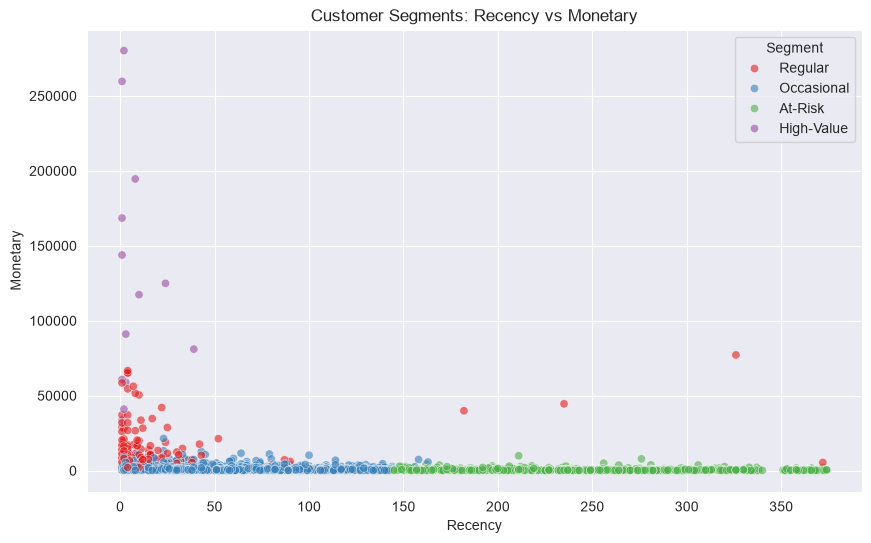

In [14]:
# Visualize Clusters (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='Set1', alpha=0.6)
plt.title('Customer Segments: Recency vs Monetary')
plt.savefig('cluster_scatter.png', bbox_inches='tight')
plt.show()

In [15]:
# Save models for Streamlit
joblib.dump(scaler, 'rfm_scaler.pkl')
joblib.dump(kmeans, 'rfm_kmeans.pkl')
joblib.dump(label_map_dict, 'cluster_label_map.pkl')
print("Saved clustering models to disk.")

Saved clustering models to disk.


## 6. Recommendation System Approach (Item-based Collaborative Filtering)

In [16]:
# Create CustomerID-Description interaction matrix
# To avoid memory issues, we limit to the top 2000 most popular items
top_items = df_clean['Description'].value_counts().head(2000).index
df_subset = df_clean[df_clean['Description'].isin(top_items)]

# Pivot table: Rows = Description, Columns = CustomerID, Values = Quantity
item_user_matrix = df_subset.pivot_table(index='Description', columns='CustomerID', values='Quantity', fill_value=0)

# Convert to 1/0 (Purchased or not) to simplify similarity
item_user_matrix = (item_user_matrix > 0).astype(int)

print(f"Item-User Matrix Shape: {item_user_matrix.shape}")

Item-User Matrix Shape: (2000, 4317)


In [17]:
# Compute Cosine Similarity between items
item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_matrix.index, columns=item_user_matrix.index)

print(f"Item Similarity Matrix Shape: {item_similarity_df.shape}")

Item Similarity Matrix Shape: (2000, 2000)


In [18]:
# Function to get top 5 recommendations
def get_recommendations(product_name, similarity_matrix, top_n=5):
    if product_name not in similarity_matrix.index:
        return []
    
    similar_scores = similarity_matrix[product_name].sort_values(ascending=False)
    # Exclude the item itself
    similar_scores = similar_scores.drop(product_name)
    return similar_scores.head(top_n).index.tolist()

# Test the recommendation engine
test_product = item_similarity_df.index[0]
print(f"Recommendations for '{test_product}':")
print(get_recommendations(test_product, item_similarity_df))

Recommendations for ' 50'S CHRISTMAS GIFT BAG LARGE':
["50'S CHRISTMAS PAPER GIFT BAG", 'VINTAGE CHRISTMAS GIFT BAG LARGE ', "6 GIFT TAGS 50'S CHRISTMAS ", ' RED SPOT GIFT BAG LARGE', 'VINTAGE CHRISTMAS PAPER GIFT BAG']


In [19]:
# Precompute top 5 recommendations for all items to save loading time in Streamlit
recommendations_dict = {}
for product in item_similarity_df.index:
    recommendations_dict[product] = get_recommendations(product, item_similarity_df)

# Save recommendations dictionary
joblib.dump(recommendations_dict, 'product_recommendations.pkl')
print("Saved product recommendations to disk.")

Saved product recommendations to disk.


In [20]:
# Also save the list of valid products
joblib.dump(list(item_similarity_df.index), 'product_list.pkl')

print("All tasks completed successfully!")

All tasks completed successfully!
